# Exploratory Data Analysis: Missing Data Identification

This notebook performs a systematic check across all datasets (APTOS, Messidor, ODIR) to identify missing items, including:
- Images listed in annotations but missing from local storage.
- Images present in local storage but missing from annotation files.
- Missing labels or corrupted entries in annotation files.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import yaml

# Load configuration
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

project_root = os.path.abspath('..')
print(f"Project Root: {project_root}")

Project Root: /Users/luislasso/Repos/dr_cross_dataset


## 1. Helper Function for Missing Data Analysis

In [2]:
def analyze_missing_data(dataset_name, csv_path, img_folder, id_column, extension='.png'):
    print(f"--- Analyzing {dataset_name} ---")
    
    if not os.path.exists(csv_path):
        print(f"Error: CSV not found at {csv_path}")
        return None
    
    # Load annotations
    if csv_path.endswith('.xlsx'):
        df = pd.read_excel(csv_path)
    else:
        df = pd.read_csv(csv_path)
        
    total_records = len(df)
    
    # Check for missing images
    missing_images = []
    for _, row in df.iterrows():
        filename = str(row[id_column])
        if not filename.endswith(extension):
            filename += extension
            
        img_path = os.path.join(img_folder, filename)
        if not os.path.exists(img_path):
            missing_images.append(filename)
            
    # Check for orphaned images (in folder but not in CSV)
    files_in_folder = set([f for f in os.listdir(img_folder) if f.endswith(extension)])
    ids_in_csv = set([str(id) + (extension if not str(id).endswith(extension) else '') for id in df[id_column]])
    orphaned_images = files_in_folder - ids_in_csv
    
    print(f"Total records in CSV: {total_records}")
    print(f"Total images in folder: {len(files_in_folder)}")
    print(f"Missing images (in CSV but not in folder): {len(missing_images)}")
    print(f"Orphaned images (in folder but not in CSV): {len(orphaned_images)}")
    
    return {
        'dataset': dataset_name,
        'total': total_records,
        'missing': len(missing_images),
        'orphaned': len(orphaned_images)
    }

## 2. Dataset Analysis

In [3]:
results = []

# APTOS Train
aptos_dir = os.path.join(project_root, config['dataset_paths']['aptos'])
results.append(analyze_missing_data(
    'APTOS Train', 
    os.path.join(aptos_dir, 'train.csv'), 
    os.path.join(aptos_dir, 'train_images'), 
    'id_code'
))

# APTOS Test
results.append(analyze_missing_data(
    'APTOS Test', 
    os.path.join(aptos_dir, 'test.csv.xls'), 
    os.path.join(aptos_dir, 'test_images'), 
    'id_code'
))

# Messidor
messidor_dir = os.path.join(project_root, config['dataset_paths']['messidor'])
results.append(analyze_missing_data(
    'Messidor', 
    os.path.join(messidor_dir, 'messidor_data.csv'), 
    os.path.join(messidor_dir, 'images'), 
    'id_code',
    extension='.jpg' # Messidor uses .jpg
))

# ODIR
odir_dir = os.path.join(project_root, config['dataset_paths']['odir'])
results.append(analyze_missing_data(
    'ODIR Training', 
    os.path.join(odir_dir, 'ODIR-5K_Training_Annotations(Updated)_V2.xlsx'), 
    os.path.join(odir_dir, 'ODIR-5K_Training_Dataset'), 
    'Left-Fundus',
    extension='.jpg'
))

--- Analyzing APTOS Train ---
Total records in CSV: 2930
Total images in folder: 113
Missing images (in CSV but not in folder): 2817
Orphaned images (in folder but not in CSV): 0
--- Analyzing APTOS Test ---
Total records in CSV: 366
Total images in folder: 366
Missing images (in CSV but not in folder): 0
Orphaned images (in folder but not in CSV): 0
--- Analyzing Messidor ---
Total records in CSV: 1744
Total images in folder: 0
Missing images (in CSV but not in folder): 1744
Orphaned images (in folder but not in CSV): 0
--- Analyzing ODIR Training ---


Total records in CSV: 3500
Total images in folder: 7000
Missing images (in CSV but not in folder): 0
Orphaned images (in folder but not in CSV): 3500


## 3. Visualization of Missing Data

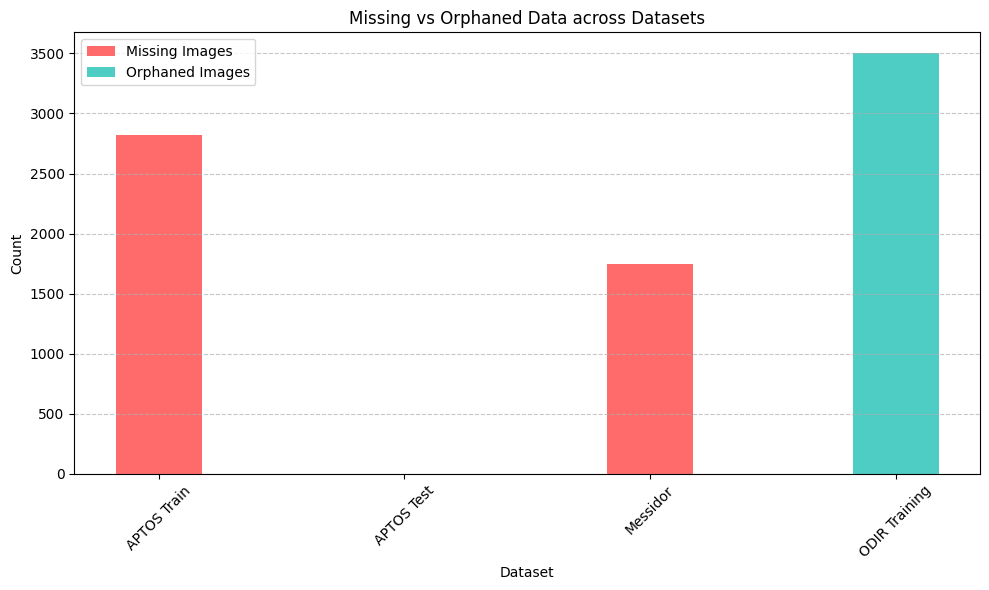

Final Summary Table:


,dataset,total,missing,orphaned
0,APTOS Train,2930,2817,0
1,APTOS Test,366,0,0
2,Messidor,1744,1744,0
3,ODIR Training,3500,0,3500


In [4]:
df_results = pd.DataFrame([r for r in results if r is not None])

plt.figure(figsize=(10, 6))
x = df_results['dataset']
width = 0.35

plt.bar(x, df_results['missing'], width, label='Missing Images', color='#ff6b6b')
plt.bar(x, df_results['orphaned'], width, bottom=df_results['missing'], label='Orphaned Images', color='#4ecdc4')

plt.xlabel('Dataset')
plt.ylabel('Count')
plt.title('Missing vs Orphaned Data across Datasets')
plt.legend()
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Final Summary Table:")
df_results